# EDA / PCA / t-SNE — Fraud Detection

Exploratory notebook (plan Sections 1-6). Reuses `src.data_quality` and `src.preprocessing` so the checks/transforms are never duplicated between here and the automated pipeline. Run `make pipeline` at least once first so `output/processed.parquet` exists.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from config import OUTPUT_DIR, RAW_DATA_PATH, TARGET_COL

df = pd.read_parquet(OUTPUT_DIR / "processed.parquet") if (OUTPUT_DIR / "processed.parquet").exists() \
    else pd.read_csv(RAW_DATA_PATH)
df.shape

(283726, 31)

## Section 1 — Data quality summary
(Full checks already run by `src/data_quality.py`; this just displays the report.)

In [2]:
import json
report = json.loads((OUTPUT_DIR / "data_quality_report.json").read_text())
report

{'shape': [284807, 31],
 'dtypes': {'Time': 'float64',
  'V1': 'float64',
  'V2': 'float64',
  'V3': 'float64',
  'V4': 'float64',
  'V5': 'float64',
  'V6': 'float64',
  'V7': 'float64',
  'V8': 'float64',
  'V9': 'float64',
  'V10': 'float64',
  'V11': 'float64',
  'V12': 'float64',
  'V13': 'float64',
  'V14': 'float64',
  'V15': 'float64',
  'V16': 'float64',
  'V17': 'float64',
  'V18': 'float64',
  'V19': 'float64',
  'V20': 'float64',
  'V21': 'float64',
  'V22': 'float64',
  'V23': 'float64',
  'V24': 'float64',
  'V25': 'float64',
  'V26': 'float64',
  'V27': 'float64',
  'V28': 'float64',
  'Amount': 'float64',
  'Class': 'int64'},
 'missing_values_total': 0,
 'missing_by_column': {},
 'duplicate_rows': 1081,
 'class_distribution': {'0': 284315, '1': 492},
 'class_distribution_pct': {'0': 99.8273, '1': 0.1727},
 'amount_outliers_iqr': 31904,
 'time_range_seconds': [0.0, 172792.0],
 'time_range_hours': 48.0,
 'duplicates_dropped': True}

## Section 2 — Univariate EDA

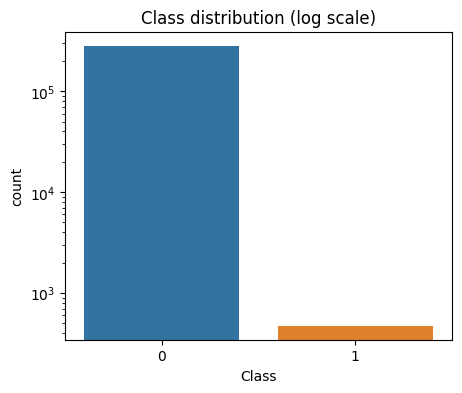

In [3]:
fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(data=df, x=TARGET_COL, ax=ax)
ax.set_yscale("log")
ax.set_title("Class distribution (log scale)")
plt.show()

In [4]:
top_skew = df.drop(columns=[TARGET_COL]).skew().abs().sort_values(ascending=False).head(6)
top_skew

Amount    16.978803
V28       11.555115
V8         8.310970
V23        5.867221
V2         4.695162
V17        3.690497
dtype: float64

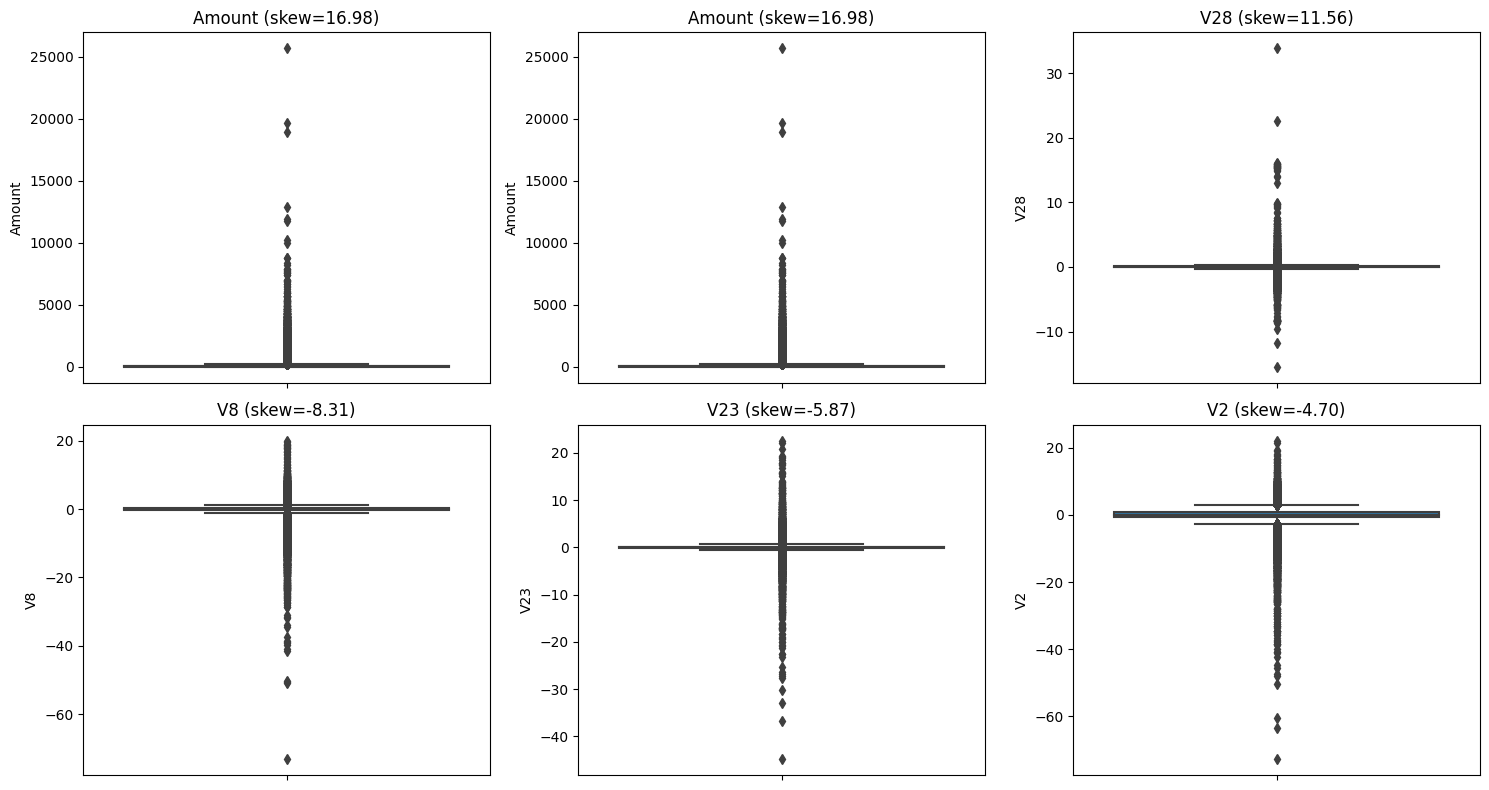

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), ["Amount"] + list(top_skew.index[:5])):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(f"{col} (skew={df[col].skew():.2f})")
plt.tight_layout()
plt.show()

## Section 2 (cont.) — Bivariate / correlation

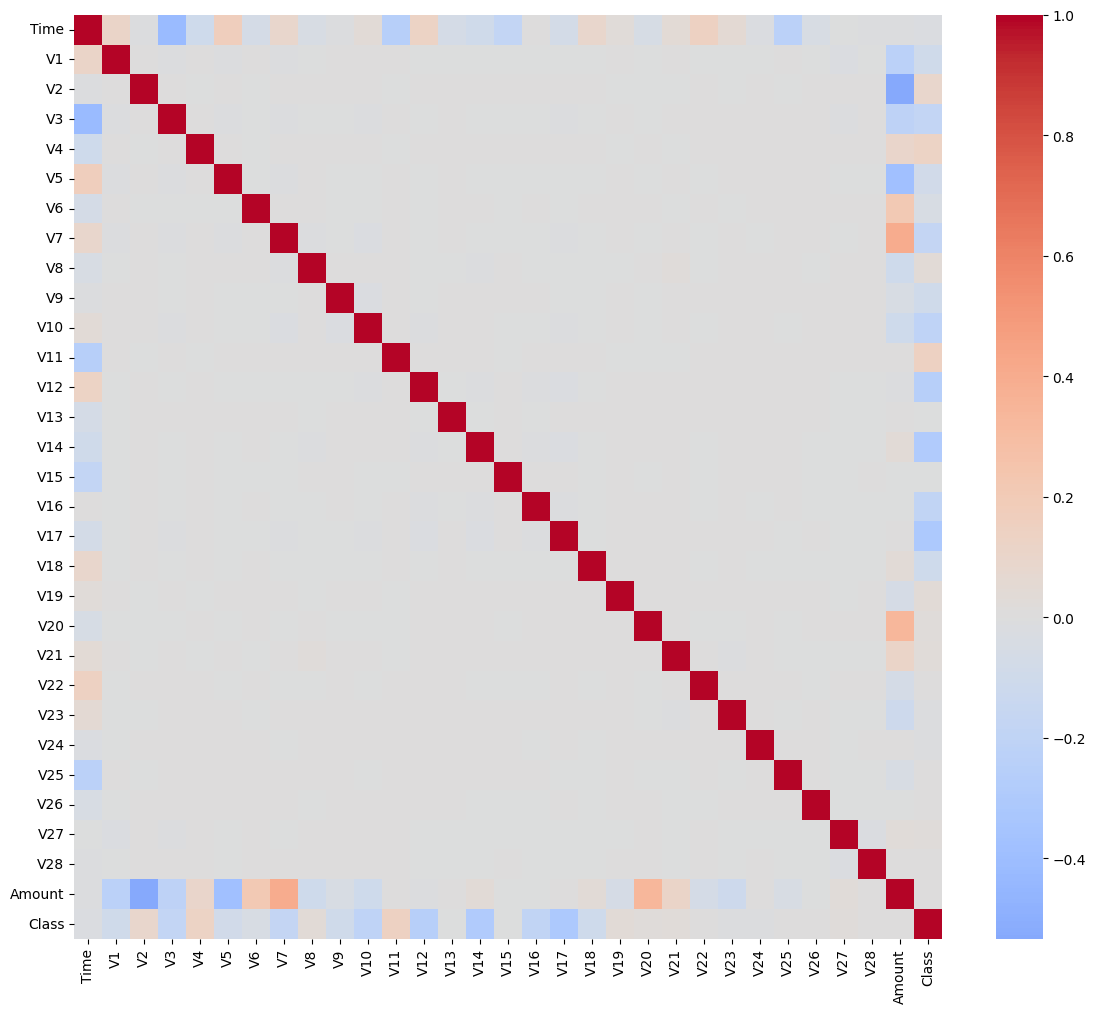

In [6]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
plt.show()

In [7]:
fraud_corr = corr[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False)
fraud_corr.head(10)

V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64

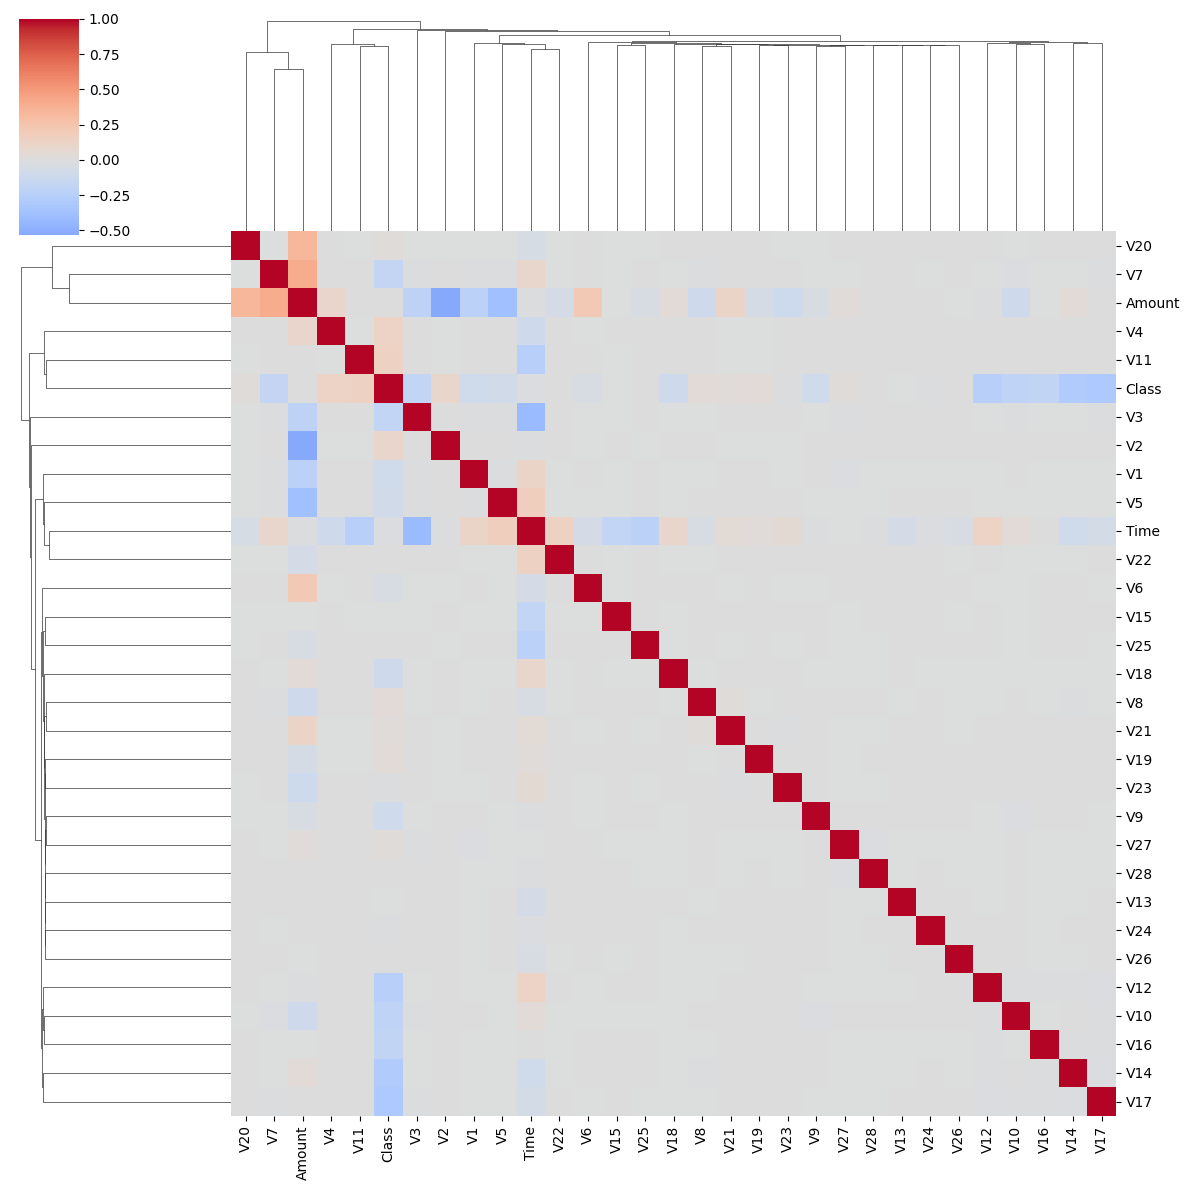

In [8]:
sns.clustermap(corr, cmap="coolwarm", center=0, figsize=(12, 12))
plt.show()

## Section 3 — PCA / t-SNE

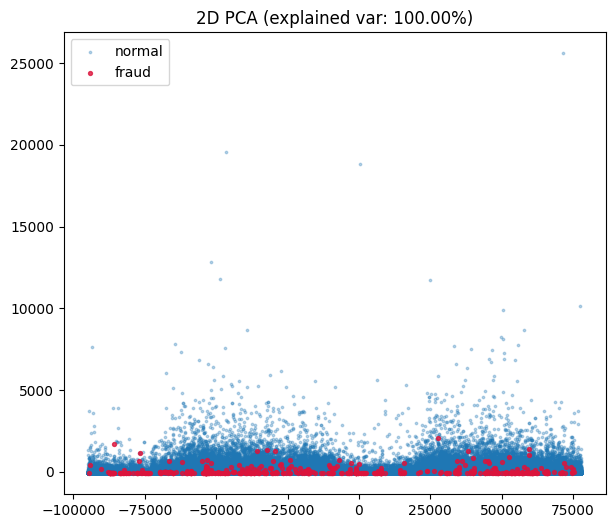

In [9]:
from sklearn.decomposition import PCA
X = df.drop(columns=[TARGET_COL])
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X)
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(pcs[df[TARGET_COL]==0,0], pcs[df[TARGET_COL]==0,1], s=3, alpha=0.3, label="normal")
ax.scatter(pcs[df[TARGET_COL]==1,0], pcs[df[TARGET_COL]==1,1], s=8, alpha=0.8, label="fraud", color="crimson")
ax.legend(); ax.set_title(f"2D PCA (explained var: {pca.explained_variance_ratio_.sum():.2%})")
plt.show()

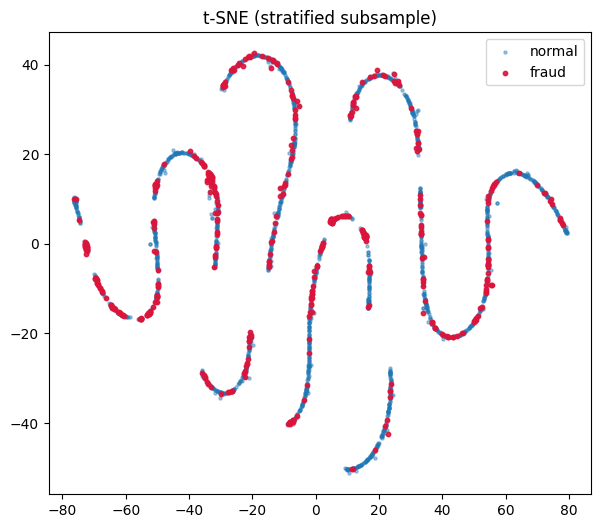

In [10]:
# t-SNE on a stratified subsample (full 285K rows is impractical for t-SNE)
from sklearn.manifold import TSNE
sub = df.groupby(TARGET_COL, group_keys=False).apply(lambda g: g.sample(min(len(g), 2000), random_state=42))
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb = tsne.fit_transform(sub.drop(columns=[TARGET_COL]))
fig, ax = plt.subplots(figsize=(7,6))
labels = sub[TARGET_COL].values
ax.scatter(emb[labels==0,0], emb[labels==0,1], s=5, alpha=0.4, label="normal")
ax.scatter(emb[labels==1,0], emb[labels==1,1], s=10, alpha=0.9, label="fraud", color="crimson")
ax.legend(); ax.set_title("t-SNE (stratified subsample)")
plt.show()

**Talking point:** PCA shows substantial overlap between classes in 2D; t-SNE reveals more separable local clusters — motivating non-linear tree-based models over plain logistic regression for this problem.